1) Load Dataset

In [ ]:
import pandas as pd
import numpy as np

# Upload file manually in Colab
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('creditcard.csv')

df.head()
df.info()
df.describe()

Saving creditcard.csv to creditcard.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


2) Clean Transaction Data

In [ ]:
# Check missing values
df.isnull().sum()

# Remove duplicates
df = df.drop_duplicates()

# Normalize Amount (important for ML / analysis)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])

# Drop original if needed
df = df.drop(columns=['Amount'])

# Example 1: Duplicate transaction rows → same fraud counted twice
# Example 2: Large amounts dominate analysis → scaling fixes this

3) Analyze User Transactions

In [ ]:
# Total transactions
total_txns = len(df)

# Fraud vs Non-Fraud
fraud_counts = df['Class'].value_counts()

# Average transaction value
avg_amount = df['Amount_scaled'].mean()

fraud_counts, avg_amount

(Class
 0    283253
 1       473
 Name: count, dtype: int64,
 np.float64(-5.409346726214081e-17))

Add grouping logic

<Axes: xlabel='Hour'>

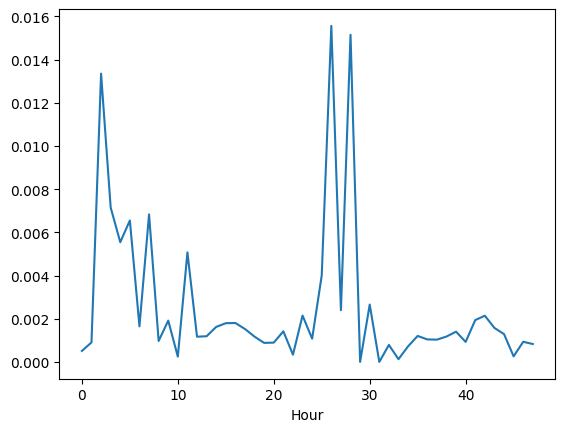

In [ ]:
# Time-based analysis
df['Hour'] = df['Time'] // 3600

df.groupby('Hour')['Class'].mean().plot()

# Examples:
# Example 1: Fraud spikes at night hours
# Example 2: High-value transactions have higher fraud probability

4) Detect Anomalies

In [ ]:
# Use simple statistical method first (don’t jump to ML blindly)
# Z-score method
from scipy.stats import zscore

df['z_score'] = zscore(df['Amount_scaled'])

# Flag anomalies
df['anomaly'] = df['z_score'].abs() > 3

df['anomaly'].head()

# Examples:
# Example 1: Transaction suddenly 50x higher than normal → anomaly
# Example 2: Many small transactions in seconds → anomaly pattern

,anomaly
0,False
1,False
2,False
3,False
4,False


Isolation Forest (better)

In [ ]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.01)
df['anomaly_iso'] = iso.fit_predict(df[['Amount_scaled']])

# -1 = anomaly
df['anomaly_iso'] = df['anomaly_iso'].map({1:0, -1:1})

5) Segment Customers by Risk

In [ ]:
# (No customer_id → simulate risk using behavior)
# Risk score based on amount + anomaly
df['risk_score'] = (
    df['Amount_scaled'].abs() * 0.5 +
    df['anomaly_iso'] * 0.5
)

# Create segments
df['risk_segment'] = pd.cut(
    df['risk_score'],
    bins=[-1, 0.5, 1.5, 3],
    labels=['Low', 'Medium', 'High']
)

df['risk_segment'].value_counts()
# Examples:
# Example 1: High amount + anomaly → High risk
# Example 2: Normal amount + no anomaly → Low risk

,count
risk_segment,
Low,268072
Medium,11591
High,2371


6) Calculate Fraud Percentage

In [11]:
fraud_percentage = (df['Class'].sum() / len(df)) * 100
fraud_percentage
# Examples:
# Example 1: 0.17% → highly imbalanced dataset
# Example 2: If >5% → suspicious dataset quality

np.float64(0.1667101358352777)

7) Identify Top Fraud Cases

In [12]:
fraud_cases = df[df['Class'] == 1]

top_fraud = fraud_cases.sort_values(by='Amount_scaled', ascending=False).head(10)

top_fraud
# Examples:
# Example 1: Highest fraud transaction value
# Example 2: Repeated fraud patterns in short time

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V27,V28,Class,Amount_scaled,Hour,z_score,anomaly,anomaly_iso,risk_score,risk_segment
176049,122608.0,-2.003460,-7.159042,-4.050976,1.309580,-2.058102,-0.098621,2.880083,-0.727484,1.460381,...,-0.397557,0.314262,1,8.136603,34.0,8.136603,True,1,4.568302,NaN
6971,9064.0,-3.499108,0.258555,-4.489558,4.853894,-6.974522,3.628382,5.431271,-1.946734,-0.775680,...,1.985913,-0.900452,1,6.873859,2.0,6.873859,True,1,3.936929,NaN
249167,154278.0,-1.600211,-3.488130,-6.459303,3.246816,-1.614608,-1.260375,0.288223,-0.048964,-0.734975,...,0.152947,0.477775,1,5.656801,42.0,5.656801,True,1,3.328401,NaN
89190,62467.0,-5.344665,-0.285760,-3.835616,5.337048,-7.609909,3.874668,1.289630,0.201742,-3.003532,...,1.520613,-1.115937,1,5.246376,17.0,5.246376,True,1,3.123188,NaN
81609,59011.0,-2.326922,-3.348439,-3.513408,3.175060,-2.815137,-0.203363,-0.892144,0.333226,-0.802005,...,0.302324,0.536375,1,5.196056,16.0,5.196056,True,1,3.098028,NaN
95597,65385.0,-2.923827,1.524837,-3.018758,3.289291,-5.755542,2.218276,-0.509995,-3.569444,-1.016592,...,1.510206,-0.324706,1,5.055041,18.0,5.055041,True,1,3.027521,NaN
199896,133184.0,-1.212682,-2.484824,-6.397186,3.670562,-0.863375,-1.855855,1.017732,-0.544704,-1.703378,...,0.212663,0.431095,1,4.978164,36.0,4.978164,True,1,2.989082,High
10690,18088.0,-12.224021,3.854150,-12.466766,9.648311,-2.726961,-4.445610,-21.922811,0.320792,-4.433162,...,3.052358,-0.775036,1,4.514464,5.0,4.514464,True,1,2.757232,High
249239,154309.0,-0.082983,-3.935919,-2.616709,0.163310,-1.400952,-0.809419,1.501580,-0.471000,1.519743,...,-0.170947,0.126221,1,4.027641,42.0,4.027641,True,1,2.513821,High
233258,147501.0,-1.611877,-0.408410,-3.829762,6.249462,-3.360922,1.147964,1.858425,0.474858,-3.838399,...,-0.136243,-0.009852,1,3.625403,40.0,3.625403,True,0,1.812702,High
